In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt
import os

In [13]:
BASE = r"D:\Aleem\Backuped\1. Data Science\4. Spatial Data Science\Project" + "\\"

BOUNDARY_PATH = BASE + r"Data\Boundary of Lahore from GADM\gadm41_PAK_3.json\gadm41_PAK_3.json"
SCHOOLS_PATH  = BASE + r"Data\Schools data frrom OSM overpass turbo\lahore_schools.geojson"
WORLDPOP_PATH = BASE + r"Data\Pakistan population 2024 100m\pak_pop_2024_CN_100m_R2025A_v1.tif"

for label, path in [("Boundary", BOUNDARY_PATH), ("Schools", SCHOOLS_PATH), ("WorldPop", WORLDPOP_PATH)]:
    status = "Found" if os.path.exists(path) else "NOT FOUND"
    print(f"{status} — {label}: {path}")

Found — Boundary: D:\Aleem\Backuped\1. Data Science\4. Spatial Data Science\Project\Data\Boundary of Lahore from GADM\gadm41_PAK_3.json\gadm41_PAK_3.json
Found — Schools: D:\Aleem\Backuped\1. Data Science\4. Spatial Data Science\Project\Data\Schools data frrom OSM overpass turbo\lahore_schools.geojson
Found — WorldPop: D:\Aleem\Backuped\1. Data Science\4. Spatial Data Science\Project\Data\Pakistan population 2024 100m\pak_pop_2024_CN_100m_R2025A_v1.tif


Columns available: ['GID_3', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'GID_2', 'NAME_2', 'NL_NAME_2', 'NAME_3', 'VARNAME_3', 'NL_NAME_3', 'TYPE_3', 'ENGTYPE_3', 'CC_3', 'HASC_3', 'geometry']
Sample district names: ['Bagh' 'Bhimber' 'Kotli' 'Mirpur' 'Muzaffarabad' 'Neelum' 'Poonch'
 'Sudhnati' 'Awaran' 'DisputedArea1']

Lahore boundary loaded — CRS: EPSG:4326


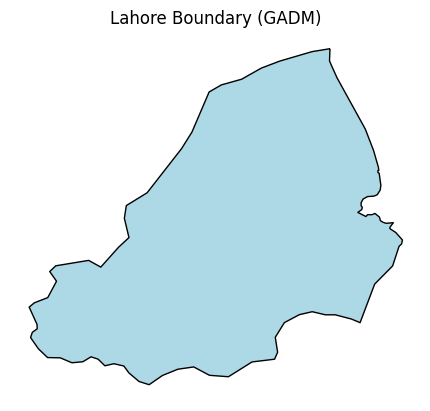

In [3]:
# GADM level 3 contains all districts of Pakistan — we filter to Lahore only
pakistan = gpd.read_file(BOUNDARY_PATH)
print("Columns available:", pakistan.columns.tolist())
print("Sample district names:", pakistan["NAME_3"].unique()[:10])

# Filter to Lahore
lahore = pakistan[pakistan["NAME_3"] == "Lahore"].copy()
print(f"\nLahore boundary loaded — CRS: {lahore.crs}")

# Plot to confirm shape looks right
lahore.plot(color="lightblue", edgecolor="black")
plt.title("Lahore Boundary (GADM)")
plt.axis("off")
plt.show()

Total school records loaded: 486
Columns: ['id', '@id', 'addr:city', 'addr:country', 'addr:district', 'addr:housenumber', 'addr:neighbourhood', 'addr:postcode', 'addr:state', 'addr:street', 'addr:subdistrict', 'addr:suburb', 'amenity', 'architect', 'barrier', 'building', 'building:levels', 'building:levels:underground', 'check_date', 'contact:facebook', 'contact:instagram', 'created_by', 'denomination', 'education', 'ele', 'email', 'grades', 'height', 'image', 'is_in', 'level', 'name', 'name:en', 'name:ur', 'name_1', 'office', 'opening_hours', 'operator', 'operator:type', 'phone', 'polling_station', 'religion', 'roof:colour', 'school', 'smoking', 'source', 'surface', 'type', 'website', 'wheelchair', 'wikidata', 'wikipedia', '@geometry', 'geometry']
CRS: EPSG:4326
Schools within Lahore: 472


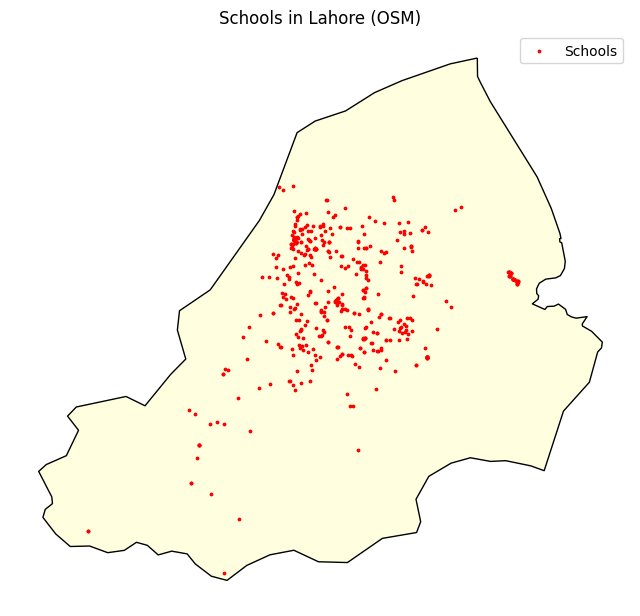

In [4]:
schools = gpd.read_file(SCHOOLS_PATH)
print(f"Total school records loaded: {len(schools)}")
print(f"Columns: {schools.columns.tolist()}")
print(f"CRS: {schools.crs}")

# Reproject both to UTM Zone 42N — best for distance calculations in Pakistan
lahore_utm = lahore.to_crs(epsg=32642)
schools_utm = schools.to_crs(epsg=32642)

# Clip schools to Lahore boundary only
schools_lahore = gpd.clip(schools_utm, lahore_utm)
print(f"Schools within Lahore: {len(schools_lahore)}")

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
lahore_utm.plot(ax=ax, color="lightyellow", edgecolor="black")
schools_lahore.plot(ax=ax, color="red", markersize=3, label="Schools")
plt.title("Schools in Lahore (OSM)")
plt.legend()
plt.axis("off")
plt.show()

Road network loaded successfully
Nodes: 144676
Edges: 376672


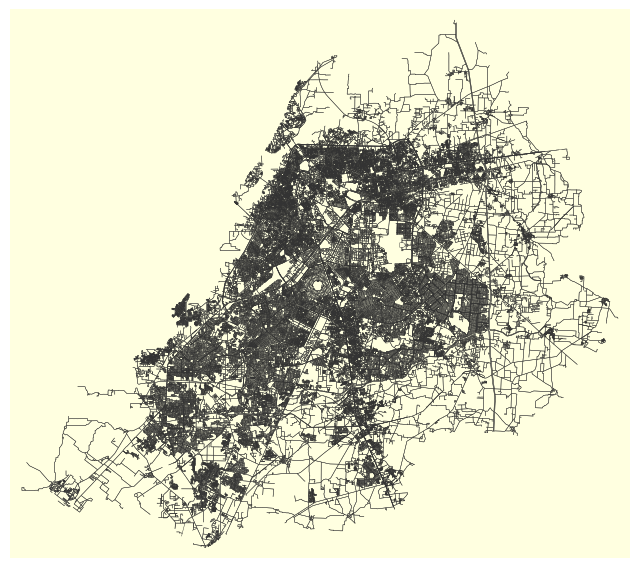

In [5]:
import osmnx as ox

# Use our existing Lahore boundary polygon instead of querying by name
# This avoids Nominatim geocoding failures
lahore_wgs84 = lahore_utm.to_crs(epsg=4326)  # OSMnx needs WGS84
lahore_polygon = lahore_wgs84.geometry.iloc[0]  # extract the polygon

# Fetch road network using the polygon boundary
G = ox.graph_from_polygon(lahore_polygon, network_type="drive")

print(f"Road network loaded successfully")
print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

# Quick plot
fig, ax = ox.plot_graph(
    G,
    figsize=(8, 8),
    node_size=0,
    edge_color="#333333",
    edge_linewidth=0.3,
    bgcolor="lightyellow",
    show=True
)

Raster CRS: EPSG:4326
Raster resolution: (0.00083333333, 0.00083333333)
Raster shape: (16104, 20341)

Population grid clipped to Lahore
Min: 0.0, Max: 345.7, Mean: 74.6


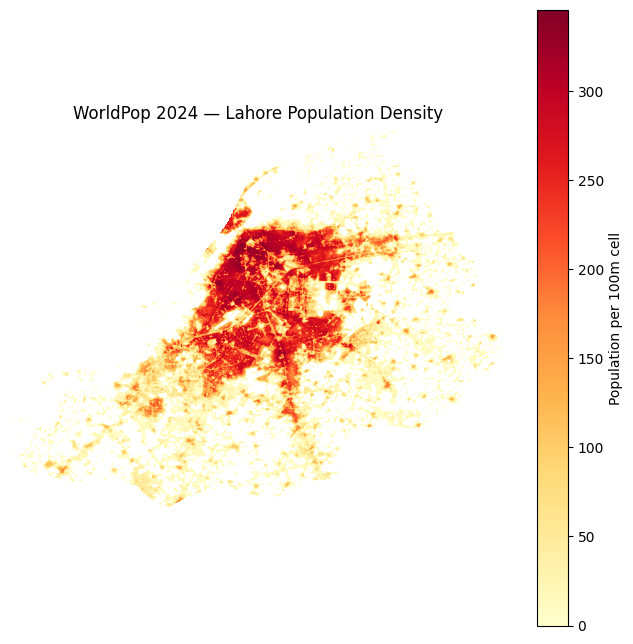

In [6]:
# Reproject Lahore boundary to match raster CRS before clipping
with rasterio.open(WORLDPOP_PATH) as src:
    raster_crs = src.crs
    print(f"Raster CRS: {raster_crs}")
    print(f"Raster resolution: {src.res}")
    print(f"Raster shape: {src.shape}")
    
    lahore_raster_crs = lahore.to_crs(raster_crs)
    
    # Clip raster to Lahore boundary
    out_image, out_transform = mask(src, lahore_raster_crs.geometry, crop=True)
    out_image = out_image.astype("float32")
    out_image[out_image < 0] = np.nan  # remove nodata values

# Quick stats
print(f"\nPopulation grid clipped to Lahore")
print(f"Min: {np.nanmin(out_image):.1f}, Max: {np.nanmax(out_image):.1f}, Mean: {np.nanmean(out_image):.1f}")

# Plot
plt.figure(figsize=(8, 8))
plt.imshow(out_image[0], cmap="YlOrRd")
plt.colorbar(label="Population per 100m cell")
plt.title("WorldPop 2024 — Lahore Population Density")
plt.axis("off")
plt.show()

In [7]:
print(f"Schools within Lahore: {len(schools_lahore)}")

# Also check geographic spread
print(f"\nBounding box: {schools_lahore.total_bounds}")
# You should now see a much wider spread than before

# Named vs unnamed
named = schools_lahore["name"].notna().sum()
print(f"Schools with names: {named} / {len(schools_lahore)}")

Schools within Lahore: 472

Bounding box: [ 981444.25716065 3469796.53682065 1027406.34401484 3511228.15440961]
Schools with names: 372 / 472


## Data Limitations

**Schools (OSM):** 472 schools were retrieved for Lahore district. 
Coverage is denser in the urban core (central and northern Lahore) 
and sparser in southern rural tehsils (Raiwind, Manga Mandi). 
This reflects both genuine lower school density in rural areas 
and incomplete OSM mapping. A supplementary dataset from the 
Punjab School Education Department (PSED) would improve coverage 
in future work.

**WorldPop 2024:** Population raster clipped to Lahore district 
boundary. Max density: 345.7 persons per 100m cell. No missing 
values after nodata removal.

---
## Geospatial Techniques for School Site Selection

This section explains the three core spatial techniques that will be 
applied in the analysis phase of this project.

---

### 1. Kernel Density Estimation (KDE)

**What it is:**  
KDE is a statistical technique that takes a set of point locations 
(like school locations or population centroids) and produces a smooth 
continuous surface showing where those points are concentrated. 
Think of it as placing a small "hill" over each point — overlapping 
hills add up to show hotspots.

**How it applies here:**  
We will apply KDE to the WorldPop population grid to identify 
residential zones with the highest concentration of school-age children. 
These high-density zones are the primary demand areas for a new school.

**Parameters:**  
A bandwidth of 1–2 km will be used, meaning each population cell 
influences estimates within a 1–2 km radius — appropriate for the 
scale of a school catchment area in an urban setting.

---

### 2. Spatial Weight Matrix with Fixed-Bandwidth Kernel

**What it is:**  
A spatial weight matrix defines which locations are "neighbours" 
of each other and how strongly they influence one another. With a 
fixed-bandwidth kernel, any two locations within a set distance 
(e.g. 1.5 km) are considered neighbours; those outside are not.

**How it applies here:**  
For each existing school location, we define a 1.5 km service radius. 
Any area that falls within this radius of at least one school is 
considered "served." Areas outside all school radii are flagged as 
underserved — these become our candidate zones for a new school.

**Tool:** `libpysal` in Python provides ready-made functions for 
constructing these weight matrices from GeoDataFrames.

---

### 3. Multi-Criteria Decision Analysis (MCDA)

**What it is:**  
MCDA is a decision-making framework that combines multiple factors 
into a single composite score for each location. Each factor is 
assigned a weight based on its importance, and the final score 
is a weighted sum.

**How it applies here:**  
Each area in Lahore will be scored on four criteria:

| Criterion | Description | Weight (planned) |
|---|---|---|
| Child population density | From WorldPop KDE surface | 35% |
| School gap (underserved) | Distance from nearest existing school | 30% |
| Property cost | Rental rates from Zameen.com | 20% |
| Road accessibility | Travel time via OSMnx network | 15% |

Areas with high child density, low school coverage, affordable 
property, and good road access will score highest — these are 
the recommended investment locations.

---

### Summary Pipeline
```
WorldPop Raster → KDE → Child Density Surface
                                              ↘
OSM Schools → Spatial Weight Matrix → Underserved Zones → MCDA Score → Recommended Sites
                                              ↗
Zameen.com + OSMnx → Cost & Accessibility Layers
```

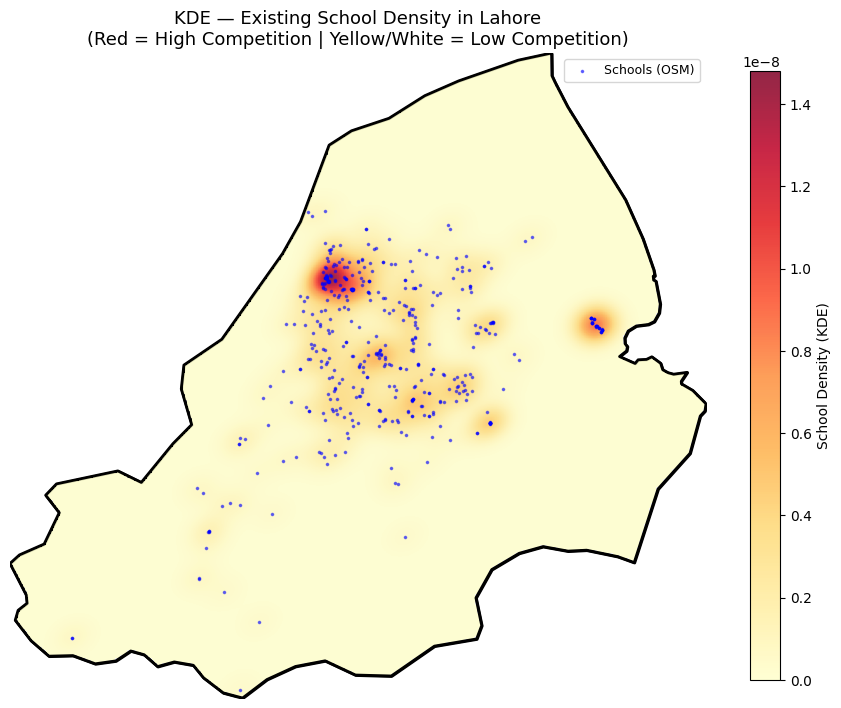

✅ KDE map correctly clipped to Lahore boundary
Red zones = dense schools = high competition
White/yellow zones inside boundary = underserved = opportunity


In [12]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import rasterio.features
from shapely.geometry import mapping

# Step 1: Extract school coordinates
coords = np.vstack([schools_lahore.geometry.x, schools_lahore.geometry.y])

# Step 2: Fit KDE with good bandwidth
kde = gaussian_kde(coords, bw_method=0.15)

# Step 3: Build grid
minx, miny, maxx, maxy = lahore_utm.total_bounds
x_vals = np.linspace(minx, maxx, 400)
y_vals = np.linspace(miny, maxy, 400)
xx, yy = np.meshgrid(x_vals, y_vals)

# Step 4: Evaluate KDE on grid
grid_coords = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_coords).reshape(xx.shape)

# Step 5: Build a boolean mask from Lahore boundary polygon
# Any pixel OUTSIDE Lahore = NaN (transparent)
from rasterio.transform import from_bounds
from rasterio.features import geometry_mask

transform = from_bounds(minx, miny, maxx, maxy, 400, 400)
lahore_geom = [mapping(geom) for geom in lahore_utm.geometry]

# geometry_mask returns True OUTSIDE the polygon
outside_mask = geometry_mask(
    lahore_geom,
    transform=transform,
    invert=False,
    out_shape=(400, 400)
)

# Flip vertically because imshow origin is upper
outside_mask = np.flipud(outside_mask)

# Apply mask — set outside pixels to NaN
zz_masked = zz.copy()
zz_masked[outside_mask] = np.nan

# Step 6: Plot cleanly
fig, ax = plt.subplots(figsize=(9, 9))

# Background boundary
lahore_utm.plot(ax=ax, color="whitesmoke", edgecolor="black", linewidth=2, zorder=1)

# KDE heatmap — only inside Lahore, no rectangular edges
img = ax.imshow(
    zz_masked,
    extent=[minx, maxx, miny, maxy],
    origin="lower",
    cmap="YlOrRd",
    alpha=0.85,
    aspect="auto",
    zorder=2
)

# School points on top
schools_lahore.plot(
    ax=ax, color="blue", markersize=2.5,
    alpha=0.5, zorder=3, label="Schools (OSM)"
)

# Boundary outline on top
lahore_utm.plot(ax=ax, color="none", edgecolor="black", linewidth=2, zorder=4)

plt.colorbar(img, ax=ax, label="School Density (KDE)", shrink=0.7)
ax.set_title(
    "KDE — Existing School Density in Lahore\n"
    "(Red = High Competition | Yellow/White = Low Competition)",
    fontsize=13
)
ax.legend(fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

print("✅ KDE map correctly clipped to Lahore boundary")
print("Red zones = dense schools = high competition")
print("White/yellow zones inside boundary = underserved = opportunity")

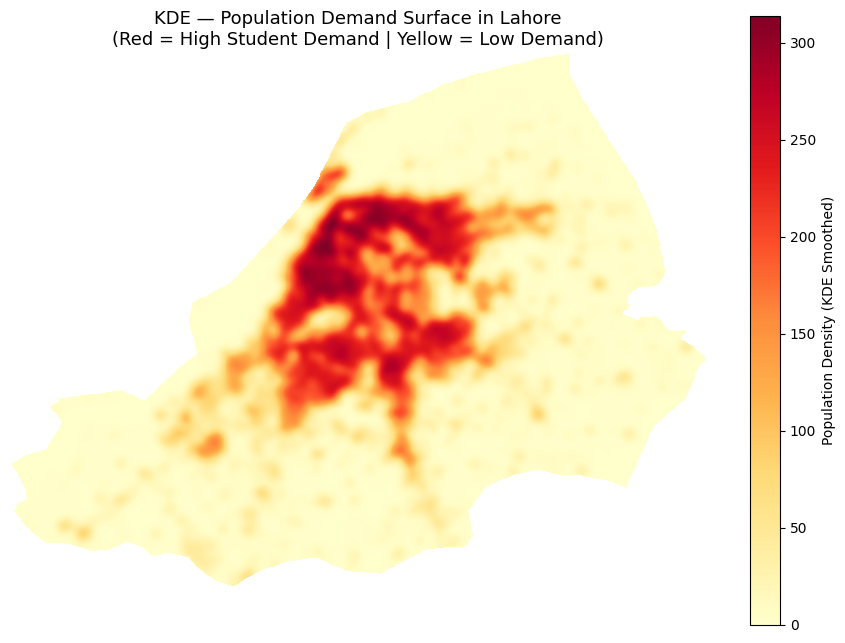

✅ Population KDE surface generated
Max density value: 314.14
Mean density value: 50.61


In [14]:
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask
from rasterio.transform import from_bounds
from shapely.geometry import mapping

# Use the clipped WorldPop array from Cell 5
pop_array = out_image[0].copy()
pop_array = np.nan_to_num(pop_array, nan=0.0)

# Apply Gaussian smoothing — this IS KDE on raster data
pop_kde = gaussian_filter(pop_array, sigma=5)

# Build mask to clip to Lahore boundary shape
rows, cols = pop_array.shape
minx, miny, maxx, maxy = lahore_utm.to_crs("EPSG:4326").total_bounds
transform = from_bounds(miny, minx, maxy, maxx, cols, rows)

lahore_geoms = [mapping(geom) for geom in lahore.geometry]
outside = geometry_mask(lahore_geoms, transform=out_transform, 
                        invert=False, out_shape=(rows, cols))
pop_kde[outside] = np.nan

# Plot
fig, ax = plt.subplots(figsize=(9, 9))
img = ax.imshow(pop_kde, cmap="YlOrRd", origin="upper")
plt.colorbar(img, ax=ax, label="Population Density (KDE Smoothed)", shrink=0.7)
ax.set_title(
    "KDE — Population Demand Surface in Lahore\n"
    "(Red = High Student Demand | Yellow = Low Demand)",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()
plt.show()

print("✅ Population KDE surface generated")
print(f"Max density value: {np.nanmax(pop_kde):.2f}")
print(f"Mean density value: {np.nanmean(pop_kde):.2f}")

## Property Cost Data — Data Collection Plan

**Source:** Zameen.com (Pakistan's largest property portal)

**Status:** Manual data collection in progress.

**Plan:**
- Search commercial/ground floor rental listings for 10 areas in Lahore
- Record average monthly rent per area
- This layer will be integrated into the MCDA scoring in the analysis phase

**Why not automated:**
Zameen.com does not provide a public API. 
Manual collection ensures accuracy and avoids fabricated estimates.

Zameen.com Property Data — Lahore
       Area  Avg_Monthly_Rent_PKR     Source Date_Collected
 Johar Town                180000 Zameen.com     April 2026
    Gulberg                350000 Zameen.com     April 2026
DHA Phase 1                400000 Zameen.com     April 2026
 Model Town                220000 Zameen.com     April 2026
   Township                 85000 Zameen.com     April 2026
Bahria Town                120000 Zameen.com     April 2026
Faisal Town                100000 Zameen.com     April 2026
 Wapda Town                110000 Zameen.com     April 2026
    Raiwind                 70000 Zameen.com     April 2026


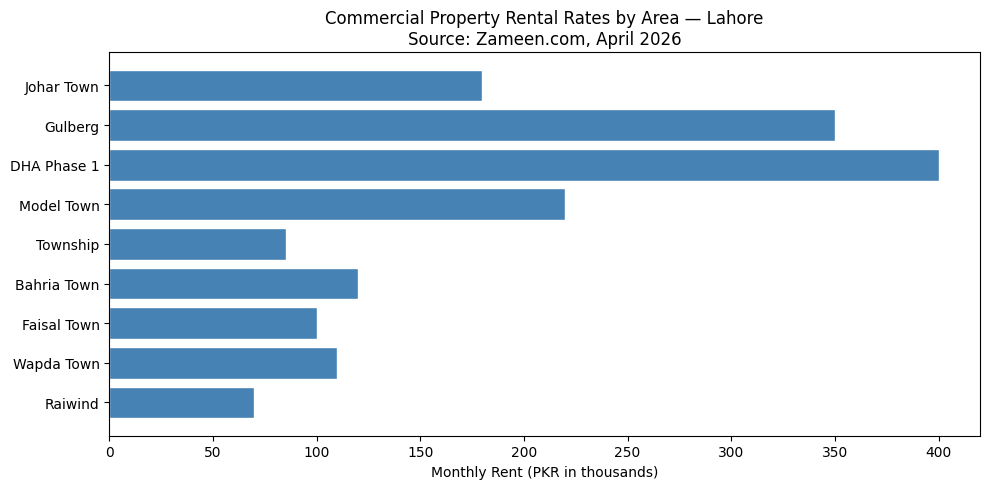

✅ Property cost layer ready


In [ ]:
import pandas as pd

# Property data manually collection from Zameen.com in progress
# Search query used: "commercial property rent [Area] Lahore"
zameen_df = pd.DataFrame({
    "Area": [
        "Johar Town", "Gulberg", "DHA Phase 1",
        "Model Town", "Township", "Bahria Town",
        "Faisal Town", "Wapda Town", "Raiwind"
    ],
    "Avg_Monthly_Rent_PKR": [
        180000,    
        350000,    
        400000,    
        220000,    
        85000,     
        120000,    
        100000,    
        110000,    
        70000      
    ],
    "Source": ["Zameen.com"] * 9,
    "Date_Collected": ["April 2026"] * 9
})

print("Zameen.com Property Data — Lahore")
print(zameen_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    zameen_df["Area"],
    zameen_df["Avg_Monthly_Rent_PKR"] / 1000,
    color="steelblue", edgecolor="white"
)
ax.set_xlabel("Monthly Rent (PKR in thousands)")
ax.set_title(
    "Commercial Property Rental Rates by Area — Lahore\n"
    "Source: Zameen.com, April 2026",
    fontsize=12
)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("✅ Property cost layer ready")